In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

import medmnist
from medmnist import INFO

from torch.utils.data import DataLoader

In [2]:
data_flag = "nodulemnist3d"

info = INFO[data_flag]

print(info)

{'python_class': 'NoduleMNIST3D', 'description': 'The NoduleMNIST3D is based on the LIDC-IDRI, a large public lung nodule dataset, containing images from thoracic CT scans. The dataset is designed for both lung nodule segmentation and 5-level malignancy classification task. To perform binary classification, we categorize cases with malignancy level 1/2 into negative class and 4/5 into positive class, ignoring the cases with malignancy level 3. We split the source dataset with a ratio of 7:1:2 into training, validation and test set, and center-crop the spatially normalized images (with a spacing of 1mm×1mm×1mm) into 28×28×28.', 'url': 'https://zenodo.org/records/10519652/files/nodulemnist3d.npz?download=1', 'MD5': '8755a7e9e05a4d9ce80a24c3e7a256f3', 'url_64': 'https://zenodo.org/records/10519652/files/nodulemnist3d_64.npz?download=1', 'MD5_64': 'c47c5b7d457bf6332200d2ea6d64ecd8', 'task': 'binary-class', 'label': {'0': 'benign', '1': 'malignant'}, 'n_channels': 1, 'n_samples': {'train': 

In [3]:
DataClass = getattr(medmnist, info['python_class'])

train_dataset = DataClass(
    split='train',
    download=True
)

100%|██████████| 29.3M/29.3M [01:15<00:00, 386kB/s]


In [4]:
print(len(train_dataset))

1158


In [5]:
image, label = train_dataset[0]

print(image.shape)

print(label)

(1, 28, 28, 28)
[0]


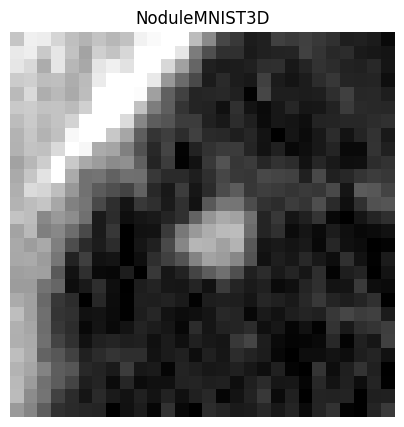

In [6]:
slice_idx = 14

plt.figure(figsize=(5,5))

plt.imshow(
    image[0, :, :, slice_idx],
    cmap="gray"
)

plt.title("NoduleMNIST3D")

plt.axis("off")

plt.show()

In [7]:
from medmnist import INFO, Evaluator
from medmnist.dataset import NoduleMNIST3D

from torch.utils.data import DataLoader

# 数据集信息
data_flag = 'nodulemnist3d'

info = INFO[data_flag]

DataClass = getattr(__import__('medmnist'), info['python_class'])

# 训练集
train_dataset = DataClass(
    split='train',
    download=True
)

# 测试集
test_dataset = DataClass(
    split='test',
    download=True
)

print("训练集数量:", len(train_dataset))
print("测试集数量:", len(test_dataset))

训练集数量: 1158
测试集数量: 310


In [8]:
img, label = train_dataset[0]

print(img.shape)

print(label)

(1, 28, 28, 28)
[0]


In [9]:
import torch
from torchvision import transforms

transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = DataClass(
    split='train',
    transform=transform,
    download=True
)

test_dataset = DataClass(
    split='test',
    transform=transform,
    download=True
)

In [10]:
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

print("DataLoader 创建成功")

DataLoader 创建成功


In [11]:
images, labels = next(iter(train_loader))

print(images.shape)

print(labels.shape)

ValueError: pic should be 2/3 dimensional. Got 4 dimensions.

In [12]:
transform = transforms.Compose([
    transforms.ToTensor()
])

In [13]:
import torch

transform = lambda x: torch.tensor(x).float()

In [14]:
train_dataset = DataClass(
    split='train',
    transform=transform,
    download=True
)

test_dataset = DataClass(
    split='test',
    transform=transform,
    download=True
)

In [15]:
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

In [16]:
images, labels = next(iter(train_loader))

print(images.shape)

print(labels.shape)

torch.Size([16, 1, 28, 28, 28])
torch.Size([16, 1])


In [63]:
import torch
import torch.nn as nn

class Simple3DCNN(nn.Module):

    def __init__(self):

        super(Simple3DCNN, self).__init__()

        self.conv_layers = nn.Sequential(

            nn.Conv3d(
                in_channels=1,
                out_channels=8,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool3d(2),

            nn.Conv3d(
                8,
                16,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool3d(2)
        )

        self.fc_layers = nn.Sequential(

            nn.Linear(16 * 7 * 7 * 7, 64),

            nn.ReLU(),

            nn.Linear(64, 2)
        )

    def forward(self, x):

     x = self.conv_layers(x)

     x = x.view(x.size(0), -1)

     x = self.fc_layers(x)

     return x

In [64]:
device = torch.device("cpu")

model = Simple3DCNN().to(device)

print(model)

Simple3DCNN(
  (conv_layers): Sequential(
    (0): Conv3d(1, 8, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (1): ReLU()
    (2): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv3d(8, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (4): ReLU()
    (5): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Linear(in_features=5488, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=2, bias=True)
  )
)


In [65]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss 和 Optimizer 创建成功")

Loss 和 Optimizer 创建成功


In [66]:
for images, labels in train_loader:

    print(images.shape)

    break

torch.Size([16, 1, 28, 28, 28])


In [67]:
outputs = model(images.float())

print(outputs.shape)

torch.Size([16, 2])


In [68]:
labels = labels.squeeze().long()

loss = criterion(outputs, labels)

print(loss.item())

0.7639466524124146


In [69]:
optimizer.zero_grad()

loss.backward()

optimizer.step()

print("第一次反向传播完成")

第一次反向传播完成


In [71]:
for epoch in range(2):

    model.train()

    total_loss = 0

    for images, labels in train_loader:

        images = images.float()

        labels = labels.squeeze().long()

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 27.8911
Epoch 2, Loss: 25.8124


In [72]:
model.eval()

Simple3DCNN(
  (conv_layers): Sequential(
    (0): Conv3d(1, 8, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (1): ReLU()
    (2): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv3d(8, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (4): ReLU()
    (5): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Linear(in_features=5488, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=2, bias=True)
  )
)

In [73]:
images, labels = next(iter(test_loader))

images = images.float()

outputs = model(images)

_, predicted = torch.max(outputs, 1)

print("Predicted:", predicted[:10])

print("True Labels:", labels[:10].squeeze())

Predicted: tensor([1, 0, 0, 0, 1, 0, 0, 0, 0, 0])
True Labels: tensor([0, 0, 0, 0, 0, 0, 0, 1, 0, 0])


In [74]:
correct = 0
total = 0

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.float()

        labels = labels.squeeze().long()

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Accuracy: {accuracy:.2f}%")

Accuracy: 84.84%


In [75]:
torch.save(
    model.state_dict(),
    "lung_nodule_classifier.pth"
)

print("模型保存成功")

模型保存成功


In [76]:
model2 = Simple3DCNN()

model2.load_state_dict(
    torch.load("lung_nodule_classifier.pth")
)

model2.eval()

print("模型加载成功")

模型加载成功


In [77]:
images, labels = next(iter(test_loader))

images = images.float()

with torch.no_grad():

    outputs = model2(images)

    _, predicted = torch.max(outputs, 1)

print("预测结果:")
print(predicted[:10])

print("真实标签:")
print(labels[:10].squeeze())

预测结果:
tensor([1, 0, 0, 0, 1, 0, 0, 0, 0, 0])
真实标签:
tensor([0, 0, 0, 0, 0, 0, 0, 1, 0, 0])


In [78]:
import matplotlib.pyplot as plt

In [79]:
images, labels = next(iter(test_loader))

images = images.float()

In [80]:
with torch.no_grad():

    outputs = model2(images)

    _, predicted = torch.max(outputs, 1)

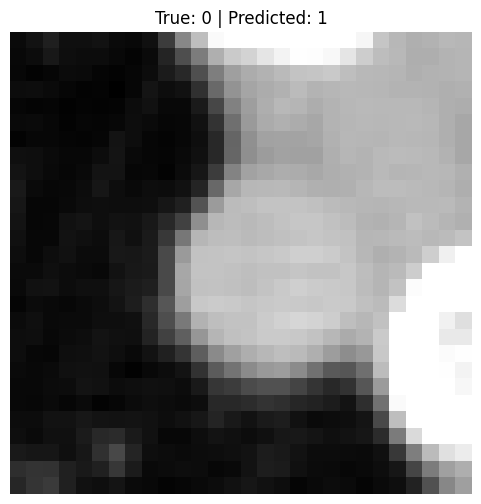

In [81]:
sample = images[0][0].numpy()

label = labels[0].item()

pred = predicted[0].item()

slice_idx = 14

plt.figure(figsize=(6,6))

plt.imshow(sample[:, :, slice_idx], cmap="gray")

plt.title(
    f"True: {label} | Predicted: {pred}"
)

plt.axis("off")

plt.show()

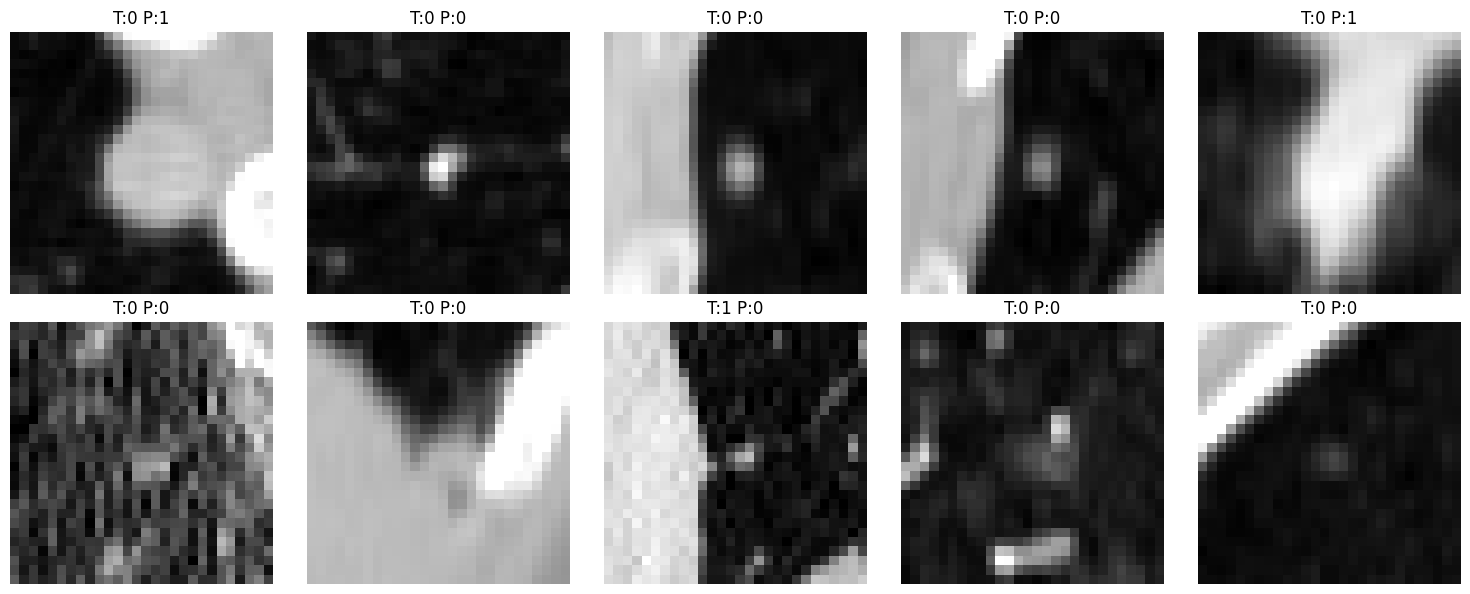

In [87]:
fig, axes = plt.subplots(2, 5, figsize=(15,6))

for i in range(10):

    sample = images[i][0].numpy()

    label = labels[i].item()

    pred = predicted[i].item()

    slice_idx = 14

    ax = axes[i//5, i%5]

    ax.imshow(
        sample[:, :, slice_idx],
        cmap="gray"
    )

    ax.set_title(
        f"T:{label} P:{pred}"
    )

    ax.axis("off")

plt.tight_layout()

plt.show()

In [84]:
plt.savefig(
    "../screenshots/ct_prediction_demo.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [88]:
plt.tight_layout()

plt.savefig(
    "../screenshots/ct_prediction_demo.png",
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

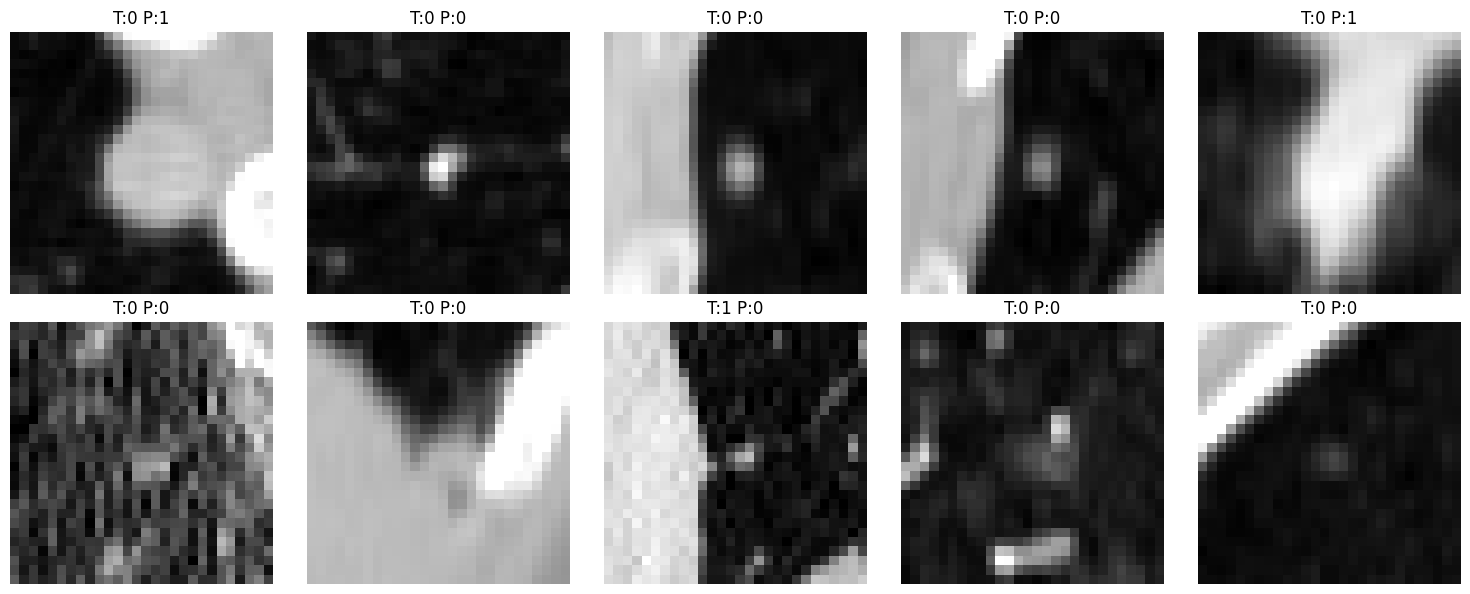

In [90]:
fig, axes = plt.subplots(2, 5, figsize=(15,6))

for i in range(10):

    sample = images[i][0].numpy()

    label = labels[i].item()

    pred = predicted[i].item()

    slice_idx = 14

    ax = axes[i//5, i%5]

    ax.imshow(
        sample[:, :, slice_idx],
        cmap="gray"
    )

    ax.set_title(
        f"T:{label} P:{pred}"
    )

    ax.axis("off")

plt.tight_layout()

plt.savefig(
    "../screenshots/ct_prediction_demo.png",
    bbox_inches="tight"
)

plt.show()